# ParkWise Nairobi — EDA on the Master Dataset
### By Victor Waweru

**What this notebook does:** looks closely at `nairobi_parking_master_dataset.csv` — 500
Nairobi parking facilities — one step at a time. Each section follows the same simple
pattern: **Process** (what we're doing and why), **Code**, then **Insight** (what we found,
explained simply).

## Two words you'll see a lot — explained first

**On-Street parking** means a car parks right along the side of a public road — think of
painted bays along a street in town, with no gate or building around them.

**Off-Street parking** means a dedicated lot or building just for parking — a mall's parking
lot, a hotel's car park, a multi-storey parking garage. It has its own defined space, away
from the road itself.

**Zones (Zone I, Zone II, etc.)** are how Nairobi County groups different parts of the city
for pricing purposes — like how a matatu fare changes depending on which route/area you're
in. Busier, more central areas (like the CBD) are usually Zone I and tend to cost more;
quieter, further-out areas are Zone II and usually cost less. **Note on this specific file:**
this particular dataset doesn't include a `zone` column — zone assignment lives in a separate
file used just for on-street facilities. So this notebook won't show a zone-by-zone chart,
but it's worth knowing what the term means since you'll see it elsewhere in the project.


## 1. Setup

**Process:** before we can look at any data, we bring in our tools — `pandas` for handling
tables, `matplotlib` and `seaborn` for drawing charts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)


## 2. Load the Data

**Process:** open the file and check its size before anything else — like counting how many
pages are in a notebook before reading it.


In [2]:
df = pd.read_csv("nairobi_parking_master_dataset.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")


Shape: 500 rows, 30 columns


In [3]:
df.head()


,osm_id,facility_name,latitude,longitude,parking_type,fee,capacity,operating_hours,access,facility_name_clean,...,overall_rating,time_period,current_speed_kmh,free_flow_speed_kmh,traffic_delay_index,traffic_data_source,total_capacity_bays,capacity_is_reported,parking_pressure_score,calibration_status
0,30121680,Unnamed Parking,-1.289606,36.815061,surface,unknown,NaN,24/7,public,"Parking Spot (-1.2896, 36.8151)",...,3.8,Peak,73,73,1.0,tomtom_flow_api,NaN,False,74.7,calibrated
1,30498595,Unnamed Parking,-1.290980,36.828267,surface,unknown,NaN,24/7,public,"Parking Spot (-1.2910, 36.8283)",...,3.7,Peak,87,87,1.0,tomtom_flow_api,NaN,False,74.7,calibrated
2,30695694,Unnamed Parking,-1.285645,36.813289,surface,unknown,NaN,24/7,public,"Parking Spot (-1.2856, 36.8133)",...,4.0,Peak,44,44,1.0,tomtom_flow_api,NaN,False,74.7,calibrated
3,295829518,Unnamed Parking,-1.259736,36.818260,surface,unknown,NaN,24/7,public,"Parking Spot (-1.2597, 36.8183)",...,3.5,Peak,52,52,1.0,tomtom_flow_api,NaN,False,74.7,calibrated
4,390312470,Unnamed Parking,-1.264105,36.811712,surface,unknown,NaN,24/7,public,"Parking Spot (-1.2641, 36.8117)",...,4.1,Peak,53,53,1.0,tomtom_flow_api,NaN,False,74.7,calibrated


**Insight:** the dataset has **500 rows (facilities) and 30 columns (pieces of
information about each one)**. Each row is one parking spot in Nairobi, and each column
tells us something about it — its name, its price, how busy the traffic is nearby, and more.


## 3. Check the Structure

**Process:** `.info()` shows us what *type* of information each column holds — text,
whole numbers, or decimals — and whether anything is missing.


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 30 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   osm_id                    500 non-null    int64  
 1   facility_name             500 non-null    str    
 2   latitude                  500 non-null    float64
 3   longitude                 500 non-null    float64
 4   parking_type              500 non-null    str    
 5   fee                       500 non-null    str    
 6   capacity                  8 non-null      float64
 7   operating_hours           500 non-null    str    
 8   access                    500 non-null    str    
 9   facility_name_clean       500 non-null    str    
 10  category                  500 non-null    str    
 11  tariff_model              500 non-null    str    
 12  base_rate_kes             500 non-null    int64  
 13  hourly_increment_kes      500 non-null    int64  
 14  penalty_fee_kes      

**Insight:** most columns are fully filled in. A few — like `capacity` and
`total_capacity_bays` — show far fewer non-empty entries than the others (we'll measure
exactly how much in the next section). Nothing wrong yet, just something to look at closely.


## 4. How Much Data Is Actually Missing?

**Process:** we calculate the exact percentage of empty cells in every column. This matters
because if a column is mostly empty, we shouldn't trust a chart built from it, or use it to
build a prediction model later.


In [5]:
missing_pct = df.isnull().mean().sort_values(ascending=False) * 100
print(missing_pct[missing_pct > 0].round(1))


capacity               98.4
total_capacity_bays    98.4
dtype: float64


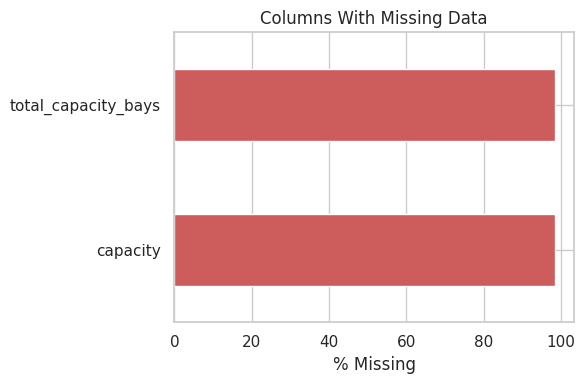

In [6]:
plt.figure(figsize=(6, 4))
missing_pct[missing_pct > 0].plot(kind='barh', color='indianred')
plt.title("Columns With Missing Data")
plt.xlabel("% Missing")
plt.tight_layout()
plt.show()


**Insight:** only two columns have missing data — **`capacity` and
`total_capacity_bays`, both 98.4% missing**. In plain words: out of 500 facilities, only
about 8 actually report how many cars they can hold. Every other column — price, category,
traffic data, and more — is 100% filled in. So this dataset is very complete overall, with
one clear, specific gap: we mostly don't know how *big* each facility is.


## 5. On-Street vs. Off-Street — How Many of Each?

**Process:** using the `category` column, we count how many facilities are On-Street (along
a road) versus Off-Street (a dedicated lot or building).


In [7]:
print(df['category'].value_counts())


category
Off-Street / Dedicated Lot    407
On-Street                      93
Name: count, dtype: int64


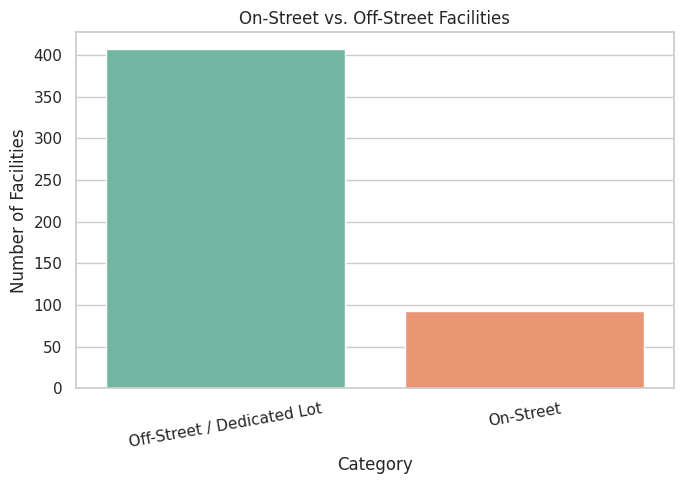

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='category', hue='category', palette='Set2', legend=False)
plt.title("On-Street vs. Off-Street Facilities")
plt.xlabel("Category")
plt.ylabel("Number of Facilities")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()


**Insight:** most facilities are **Off-Street (407 of 500, about 81%)** — dedicated
lots, garages, and building parking. Only **93 (about 19%)** are On-Street, the roadside
bays. This tells us Nairobi's tracked parking is mostly *dedicated spaces*, not just cars
lining the road.


## 6. A Closer Look — What Kind of Parking Is It?

**Process:** `category` gave us the big picture (On-Street vs Off-Street). `parking_type`
breaks it down further — is it an open lot, a multi-storey building, underground, or
something else?


In [9]:
print(df['parking_type'].value_counts())


parking_type
surface                397
street_side             92
multi-storey             8
underground              2
street_sideQ3295867      1
Name: count, dtype: int64


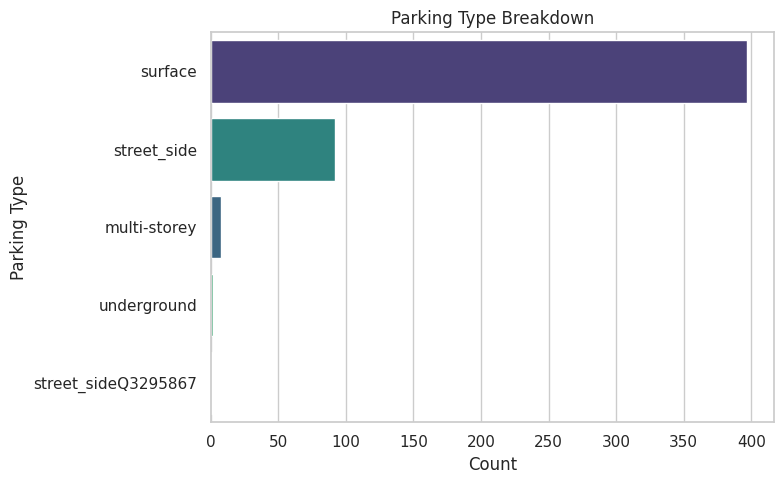

In [10]:
plt.figure(figsize=(8, 5))
order = df['parking_type'].value_counts().index
sns.countplot(data=df, y='parking_type', order=order, hue='parking_type', palette='viridis', legend=False)
plt.title("Parking Type Breakdown")
plt.xlabel("Count")
plt.ylabel("Parking Type")
plt.tight_layout()
plt.show()


**Insight:** **`surface` parking (a flat, open lot) is by far the most common — 397 of
500 facilities.** `street_side` (roadside) comes next at 92. Multi-storey buildings (8) and
underground parking (2) are rare in this dataset. One small thing worth mentioning: there's
a single row labelled `street_sideQ3295867` — that's really meant to say `street_side`, but
an extra code got stuck onto it by mistake during data collection. Just one row, easy to fix,
not something to worry about for the bigger picture.


## 7. How Much Does Parking Cost?

**Process:** we look at `base_rate_kes` — the standard price for each facility — first as
summary numbers, then as a chart.


In [11]:
print(df['base_rate_kes'].describe())


count    500.000000
mean     134.600000
std       70.446899
min       50.000000
25%      100.000000
50%      100.000000
75%      100.000000
max      300.000000
Name: base_rate_kes, dtype: float64


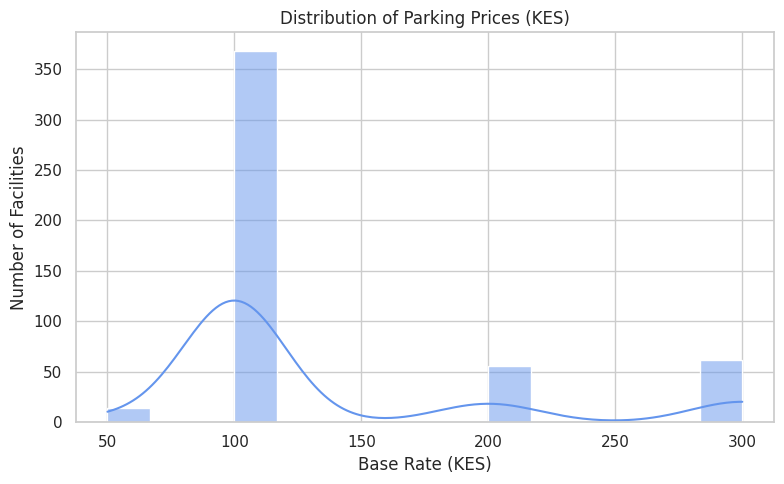

In [12]:
plt.figure(figsize=(8, 5))
sns.histplot(df['base_rate_kes'], bins=15, kde=True, color='cornflowerblue')
plt.title("Distribution of Parking Prices (KES)")
plt.xlabel("Base Rate (KES)")
plt.ylabel("Number of Facilities")
plt.tight_layout()
plt.show()


**Insight:** prices range from **50 to 300 KES**, and the middle half of all facilities
charge exactly **100 KES** (that's both the 25th and 75th percentile — a strong sign many
facilities share the same standard rate rather than pricing individually). The average is
about 135 KES, pulled up a bit by a smaller number of pricier facilities. In short: Nairobi
parking mostly follows a few common price points, not free-form pricing.


## 8. Traffic Speed vs. Delay — Do They Move Together?

**Process:** `current_speed_kmh` is how fast traffic is actually moving near a facility.
`traffic_delay_index` measures how much slower that is compared to normal (a value of 1.0
means no delay at all; higher means more congestion). We check whether these two move
together, the way we'd expect.


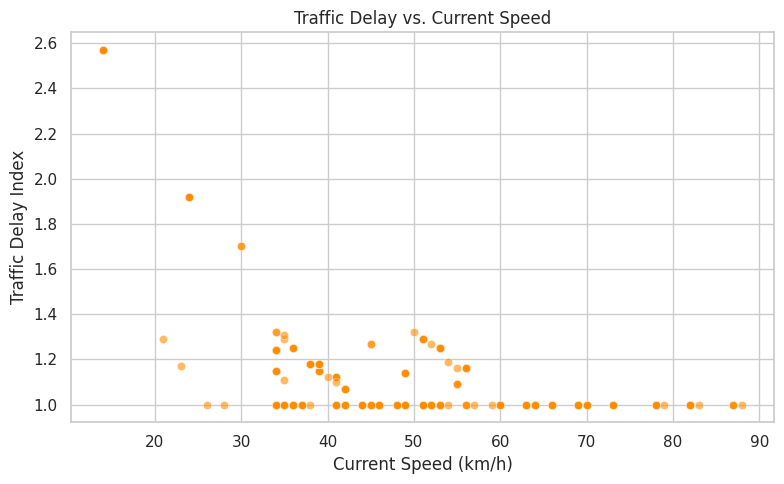

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='current_speed_kmh', y='traffic_delay_index', alpha=0.6, color='darkorange')
plt.title("Traffic Delay vs. Current Speed")
plt.xlabel("Current Speed (km/h)")
plt.ylabel("Traffic Delay Index")
plt.tight_layout()
plt.show()


**Insight:** as speed drops, the delay index rises — a clear, expected pattern.
Slower-moving traffic near a facility means more congestion. This is a good sign the traffic
data is behaving sensibly, not randomly.


## 9. Which Numbers Move Together? (Correlation Heatmap)

**Process:** a correlation number tells us how strongly two columns move together, from -1
(always opposite) to +1 (always together). A heatmap shows this for every pair of numeric
columns at once, using color instead of typing out every number.


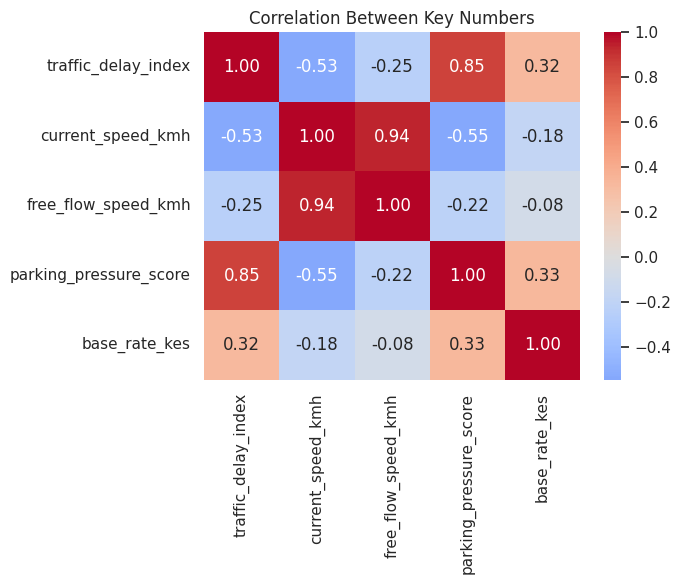

In [14]:
numeric_cols = ['traffic_delay_index', 'current_speed_kmh', 'free_flow_speed_kmh',
                'parking_pressure_score', 'base_rate_kes']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Between Key Numbers")
plt.tight_layout()
plt.show()


**Insight:** `traffic_delay_index` and `parking_pressure_score` correlate strongly at
**0.85** — when traffic is more delayed nearby, the parking pressure score tends to be
higher too. This makes sense: `parking_pressure_score` is partly built from traffic
conditions, so a strong relationship here is expected, not surprising. `base_rate_kes`
(price) barely relates to any of the traffic numbers (correlations around 0.3 or lower) —
telling us that price and congestion are mostly independent of each other in this dataset.


## 10. Facility Size — The 8 Facilities We Actually Know About

**Process:** since `capacity` is 98.4% missing, drawing a chart on it would be misleading —
almost the whole chart would just be empty. Instead, we look directly at the 8 real values
that do exist.


In [15]:
known_capacity = df[df['capacity'].notna()][['facility_name_clean', 'capacity']].sort_values('capacity', ascending=False)
known_capacity


,facility_name_clean,capacity
20,Capital Centre Parking Lot,600.0
160,Aga Khan University Hospital Parking,500.0
151,KAPS Parking Holy Family Basilica,400.0
104,KenCom CarPark,200.0
186,"Parking Spot (-1.2970, 36.8948)",50.0
363,"Parking Spot (-1.2678, 36.7999)",30.0
144,"Parking Spot (-1.2524, 36.8693)",1.0
142,"Parking Spot (-1.2527, 36.8701)",1.0


**Insight:** the 8 known facility sizes range from large, named places (600 bays at the
top) down to a couple of very small entries. Because this is only 8 out of 500 facilities,
we can't say anything general about "how big is a typical Nairobi parking facility" — we
simply don't have enough of that information yet.


## 11. Parking Pressure Score — How Busy Is Each Facility Estimated to Be?

**Process:** `parking_pressure_score` is the project's estimate of how much demand/pressure
a facility is under. We look at its overall shape across all 500 facilities.


In [16]:
print(df['parking_pressure_score'].describe())


count    500.000000
mean      78.369400
std        6.923782
min       74.700000
25%       74.700000
50%       74.700000
75%       80.200000
max      100.000000
Name: parking_pressure_score, dtype: float64


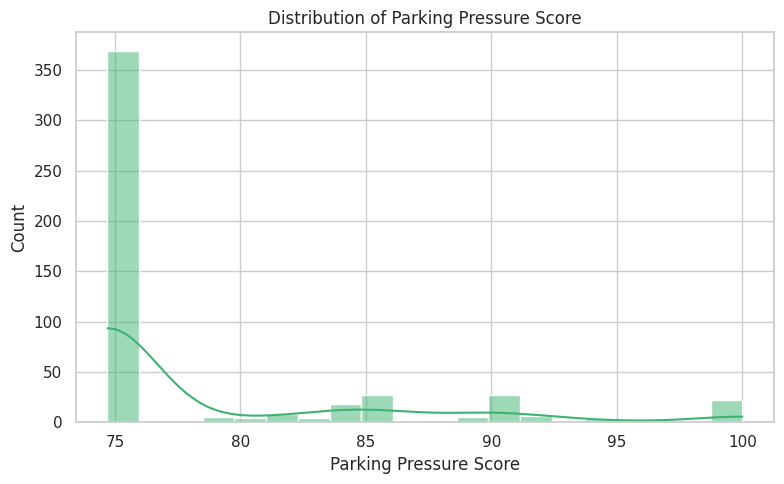

In [17]:
plt.figure(figsize=(8, 5))
sns.histplot(df['parking_pressure_score'], bins=20, kde=True, color='mediumseagreen')
plt.title("Distribution of Parking Pressure Score")
plt.xlabel("Parking Pressure Score")
plt.tight_layout()
plt.show()


**Insight:** most facilities cluster around a pressure score of about **74.7 to 80**,
with a smaller number reaching as high as 100 (maximum possible pressure). This tells us most
facilities are estimated to be under fairly similar, moderate pressure, with a smaller group
standing out as notably busier.


## 12. Who Can Actually Use These Facilities?

**Process:** `access` tells us whether a facility is open to the public or restricted, and
`fee` tells us whether payment is confirmed as required.


In [18]:
print(df['access'].value_counts())
print()
print(df['fee'].value_counts())


access
public        441
customers      26
yes            16
private        13
permissive      3
unknown         1
Name: count, dtype: int64

fee
unknown    459
yes         27
no          14
Name: count, dtype: int64


**Insight:** the large majority of facilities (441 of 500) are marked **`public`** —
open to any driver. A smaller number are restricted to **`customers`** (26) or fully
**`private`** (13). On fees, most facilities (459) simply show **`unknown`** — meaning we
don't actually know whether payment is required there, which is a real gap worth keeping in
mind: this dataset can tell us a facility's *listed* price, but not always confirm that a fee
is definitely charged.


## 13. Summary of Findings

1. **500 facilities, 30 columns, and only one real gap:** `capacity`/`total_capacity_bays`
   are 98.4% missing — everything else is fully filled in.
2. **Off-Street facilities dominate** (407 of 500, ~81%) over On-Street (93, ~19%).
3. **`surface` (open lot) is the most common parking type** (397 of 500); multi-storey and
   underground parking are rare.
4. **A small data bug exists**: one row shows `street_sideQ3295867` instead of
   `street_side` — a one-row fix, not a big issue.
5. **Prices mostly follow standard rates**: 50–300 KES, with the middle half of all
   facilities charging exactly 100 KES.
6. **Traffic delay and parking pressure move together strongly** (correlation 0.85) — this
   is expected, since pressure is calculated using traffic conditions.
7. **Price and traffic congestion are mostly unrelated** to each other (low correlation) —
   busier traffic doesn't necessarily mean a higher price.
8. **We only know the true size of 8 facilities** — far too few to generalize about typical
   facility size.
9. **Most facilities are public** (441 of 500), but **fee status is unknown for the
   majority** (459) — a real gap between "listed price" and "confirmed as chargeable."

Every insight above comes directly from running this notebook against the real 500-row file
— nothing was assumed or estimated without checking the actual numbers first.
